In [1]:
# Libraries
import numpy as np
from qiskit.quantum_info import partial_trace, Statevector
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import *
from qiskit_aer import StatevectorSimulator
import matplotlib.pyplot as plt
from matplotlib import animation
from PIL import Image
from ipywidgets import interact, widgets
from IPython.display import display, clear_output
import os
from itertools import chain

import warnings
import soundfile
warnings.filterwarnings('ignore')

backend = StatevectorSimulator(method="statevector")

In [2]:
# Functions

# qip/helper.py

def sfwht(a):
    """Fast walsh hadamard transform with scaling

    Args:
        a (flat array): array with values to be transformed

    Returns:
        input array: array of same type as input, inplace transform
    """
    n = len(a)
    k = ilog2(n)
    j = 1
    while j < n:
        for i in range(n):
            if i & j == 0:
                j1 = i + j
                x = a[i]
                y = a[j1]
                a[i], a[j1] = (x + y) / 2, (x - y) / 2
        j *= 2
    return a            

def isfwht(a):
    """Inverse of the walsh hadamard transform

    Args:
        a (array): array of values

    Returns:
        array: array with inverse transformed applied, inplace
    """
    n = len(a)
    k = ilog2(n)
    j=1
    while j< n:
        for i in range(n):
            if (i&j) == 0:
                j1=i+j 
                x=a[i]
                y=a[j1]
                a[i],a[j1]=(x+y),(x-y)
        j*=2 
    return a            

def ispow2(x):
    """am I a power of two

    Args:
        x (int): number

    Returns:
        Bool: is it a power of two? The answer
    """
    return not (x&x-1)

def nextpow2(x):
    """Returns next power of two, or identity if x is a power of two

    Args:
        x (int): number to check

    Returns:
        int: next power of two (or x if x is a power of two)
    """
    x-=1
    x|=x>>1
    x|=x>>2
    x|=x>>4
    x|=x>>8
    x|=x>>16
    x|=x>>32
    x+=1
    return x 

def ilog2(x):
    """Integer log 2"""
    return int(np.log2(x))

def grayCode(x):
    """Gray code permutation of x, to change indices"""
    return x^(x>>1)

def grayPermutation(a):
    """Gray permutes an array"""
    b = np.zeros(len(a))
    for i in range(len(a)):
        b[i] = a[grayCode(i)]
    return b

def invGrayPermutation(a):
    """inverse gray permutes an array"""
    b = np.zeros(len(a))
    for i in range(len(a)):
        b[grayCode(i)] = a[i]
    return b

def convertToAngles(audio):
    """
    Convert audio samples in [-1, 1] directly to RY angles in [0, pi].
    """
    audio = np.asarray(audio, dtype=float)
    audio = np.clip(audio, -1.0, 1.0)

    return (audio + 1.0) * np.pi / 2.0

def convertFromAngles(angles):
    """
    Convert RY angles in [0, pi] back to audio samples in [-1, 1].
    """
    angles = np.asarray(angles, dtype=float)
    angles = np.clip(angles, 0.0, np.pi)

    return 2.0 * angles / np.pi - 1.0


def convertToGrayscaleOld(arr,maxval=1,minval=0):
    """Converts encoded postprocessed statevector back to grayscale, normalized to maxval"""
    scal = 2*(maxval)/np.pi
    arr = arr * scal
    # arr = ((arr - arr.min()+minval) * (1/(arr.max() - arr.min()) * maxval))
    return arr

def convertToGrayscale(arr, maxval=1, minval=0):
    """
    Scales an array so that its minimum and maximum values lie between new_min and new_max.

    Args:
        arr (numpy.ndarray): Input array to be scaled.
        new_min (float): The desired minimum value of the scaled array.
        new_max (float): The desired maximum value of the scaled array.

    Returns:
        numpy.ndarray: Scaled array with values between new_min and new_max.
    """
    old_min = np.min(arr)
    old_max = np.max(arr)
    scaled_arr = (arr - old_min) / (old_max - old_min) * (maxval - minval) + minval
    return scaled_arr

def countr_zero(n,n_bits=8):
    """Returns the number of consecutive 0 bits 
    in the value of x, starting from the 
    least significant bit ("right")."""
    if n == 0:
        return n_bits
    count = 0
    while n & 1 == 0:
        count += 1
        n >>= 1
    return count

def preprocess_image(img):
    """Program requires flattened transpose of image array, this returns exactly that"""
    return img.T.flatten()

def readpgm(name):
    """Reads pgm P2 files"""
    with open(name) as f:
        lines = f.readlines()
    # This ignores commented lines
    for l in list(lines):
        if l[0] == '#':
            lines.remove(l)
    # here,it makes sure it is ASCII format (P2)
    assert lines[0].strip() == 'P2' 
    # Converts data to a list of integers
    data = []
    for line in lines[1:]:
        data.extend([int(c) for c in line.split()])
        
    return (np.array(data[3:]),(data[1],data[0]),data[2])

def pad_0(img,val=0):
    """Pads array with 0s to next power of two

    Args:
        img (numpy array): image, can be wide

    Returns:
        padded image: flattened image with appropiate padding for quantum algorithm
    """
    img = np.array(img)
    img.flatten()
    return np.pad(img,(0,nextpow2(len(img))-len(img)),constant_values=val)

def decodeQPIXL(state,min_pixel_val=0,max_pixel_val=255, state_to_prob = np.abs, scaling = convertToGrayscale):
    """Automatically decodes qpixl output statevector

    Args:
        state (statevector array): statevector from simulator - beware of bit ordering
        max_pixel_val (int, optional): normalization value. Defaults to 255.
        state_to_prob (function): If you made some transforms, your image 
                                    may be complex, how would you 
                                    like to make the vector real?
    Returns:
        np.array: your image, flat
    """
    state_to_prob(state)
    pv = np.zeros(len(state)//2)
    for i in range(0,len(state),2):
        pv[i//2]=np.arctan2(state[i+1],state[i])
    return scaling(pv,max_pixel_val,min_pixel_val)

def permute_bits(b,bitlength=8,shift=1):
    """cyclic permutation of bits

    Args:
        b (integer): integer to be converted
        bitlength (int, optional): how many bits do you want to permute in. Defaults to 8.
        shift (int, optional): how many bits to shift. Defaults to 1.

    Returns:
        int: integer representation of bits
    """
    b = bin(b)
    b = b[2:].zfill(bitlength)
    b = [b[(i + shift) % len(b)] for i in range(len(b))]
    return int(''.join(b),2)

def decodeAudioQCrank(state, qc):
    """
    Recover audio samples in [-1, 1] from a QCrank state.

    Qubit 0 is the auxiliary/algorithm qubit.
    Qubit 1 is the audio encoding qubit.
    Qubits 2 onward are the address qubits.
    """
    # Remove auxiliary qubit 0
    probabilities = partial_trace(state, [0]).probabilities()

    # For each address:
    # p0 = C cos²(phi/2)
    # p1 = C sin²(phi/2)
    p0 = np.clip(probabilities[0::2], 0.0, None)
    p1 = np.clip(probabilities[1::2], 0.0, None)

    # Recover phi in [0, pi]
    angles = 2.0 * np.arctan2(np.sqrt(p1), np.sqrt(p0))

    # Recover audio in [-1, 1]
    return convertFromAngles(angles)

In [3]:
def QCrank(audio_signal, compression, pre_pattern=None,post_pattern=None):
    """
    Constructs the QCrank circuit, which is a compressed FRQI circuit.
    This function takes an input audio signal represented as a 1D array, compresses it
    based on the specified compression ratio, and generates a quantum circuit that 
    encodes the audio signal. The circuit can optionally include pre- and post-pattern operations around controlled rotations.
    Args:
        audio_signal (numpy.ndarray): Audio signal represented as a 1D array of amplitudes.
        compression (float): Compression ratio as a percentage (0-100). Determines the 
                                proportion of smallest absolute values in the audio data 
                                to set to zero.
        pre_pattern (callable, optional): A function that applies a custom operation 
                                            to the circuit before a controlled rotation. 
                                            Defaults to None.
        post_pattern (callable, optional): A function that applies a custom operation 
                                            to the circuit after a controlled rotation. 
                                            Defaults to None.
    Returns:
        QuantumCircuit: A quantum circuit implementing the compressed FRQI representation 
                        of the input audio signal.
    Notes:
        - The input array is first converted to angles and preprocessed.
        - The Walsh-Hadamard Transform (WHT) is applied to the data, followed by 
            a Gray code permutation.
        - The smallest absolute values in the transformed data are set to zero based on 
            the compression parameter.
        """
    a = convertToAngles(audio_signal) # convert audio signal to angles
    a = preprocess_image(a) # need to flatten the transpose for easier decoding, 
                            # only really necessary if you want to recover an image.
                            # for classification tasks etc. transpose isn't required.
    n = len(a)
    if not ispow2(n):
        raise ValueError("The signal length must be a power of two.")
    k = ilog2(n)

    a = sfwht(a)
    a = grayPermutation(a) 
    a_sort_ind = np.argsort(np.abs(a))

    # set smallest absolute values of a to zero according to compression param
    cutoff = int((compression / 100.0) * n)
    for it in a_sort_ind[:cutoff]:
        a[it] = 0
    # print(a)
    # Construct FRQI circuit
    circuit = QuantumCircuit(k + 2)
    # Hadamard register
    circuit.h(range(2,k+2))
    circuit.x(0)
    # Compressed uniformly controlled rotation register
    ctrl, pc, i = 0, 0, 0
    while i < (2**k):
        # Reset the parity check
        pc = int(0)

        # Add RY gate
        if a[i] != 0:
            if pre_pattern is None:
                circuit.ry(a[i],1)
            else:
                pre_pattern(circuit)
                circuit.cry(a[i],0,1)
                post_pattern(circuit)
            
        # Loop over sequence of consecutive zero angles to 
        # cancel out CNOTS (or rather, to not include them)
        if i == ((2**k) - 1):
            ctrl=0
        else:
            ctrl = grayCode(i) ^ grayCode(i+1)
            ctrl = k - countr_zero(ctrl, n_bits=k+1) - 1

        # Update parity check
        pc ^= (2**ctrl)
        i += 1
        
        while i < (2**k) and a[i] == 0:
            # Compute control qubit
            if i == ((2**k) - 1):
                ctrl=0
            else:
                ctrl = grayCode(i) ^ grayCode(i+1)
                ctrl = k - countr_zero(ctrl, n_bits=k+1) - 1

            # Update parity check
            pc ^= (2**ctrl)
            i += 1
                        
        for j in range(k):
            if (pc >> j)  &  1:
                circuit.cx(k-j+1, 1)
    return circuit

def decodeAngQPIXL(state, qc, trace ,max_pixel_val=255, min_pixel_val=0):
    """Automatically decodes qpixl output statevector - taking into account 
    that there are other qubits in the cirucit - this version only returns one image. 

    Args:
        state (statevector array): statevector from simulator - beware of bit ordering
        qc (qiskit circuit): the circuit used for the state generation
        max/min_pixel_val (int, optional): normalization values. Defaults to 255/0.
    Returns:
        np.array: your image, flat
    """
    decoded_data = []
    datum=0
    to_trace = list(range(trace))
    to_trace.pop(trace-datum-1)
    test = decodeQPIXL(partial_trace(state, [qc.qubits.index(qubit) for qubit in [qc.qubits[qub] for qub in to_trace]]).probabilities())
    return convertToGrayscale(np.array([test[permute_bits(i,len(qc.qubits)-trace,datum)] for i in range(len(test))]),max_pixel_val,min_pixel_val)


QCrank Quantum Circuit:


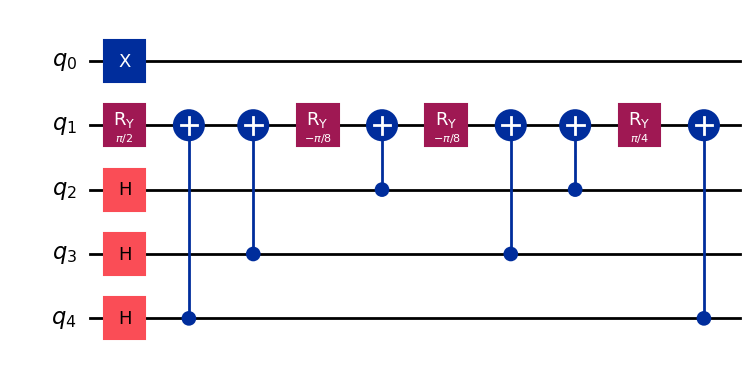

Original:
[ 0.   0.5  1.   0.5  0.  -0.5 -1.  -0.5]

Decoded:
[ 0.   0.5  1.   0.5  0.  -0.5 -1.  -0.5]

Error:
[0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
# Eight-sample toy audio signal in [-1, 1]
toy_signal = np.array([
     0.0,
     0.5,
     1.0,
     0.5,
     0.0,
    -0.5,
    -1.0,
    -0.5,
], dtype=float)

assert len(toy_signal) == 8
assert ispow2(len(toy_signal))

# Start with zero compression to test exact encoding/decoding
qc = QCrank(
    audio_signal=toy_signal,
    compression=0,
)

print("QCrank Quantum Circuit:")
display(qc.draw(output='mpl', fold=-1))

# Simulate the complete circuit
state = Statevector.from_instruction(qc)

# Decode all eight samples at once
decoded_signal = decodeAudioQCrank(state, qc)

print("Original:")
print(np.round(toy_signal, 6))

print("\nDecoded:")
print(np.round(decoded_signal, 6))

print("\nError:")
print(np.round(decoded_signal - toy_signal, 10))

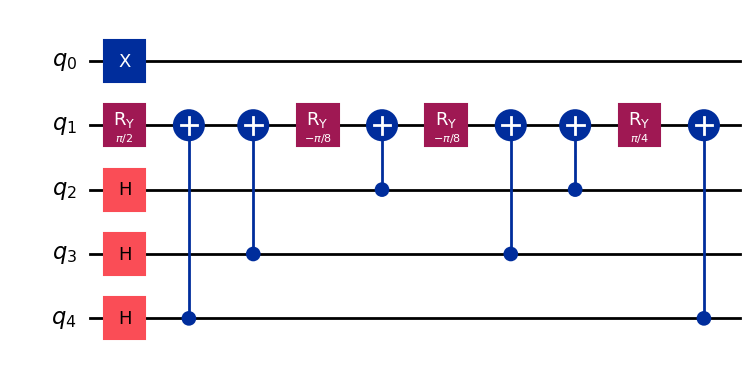

In [5]:
qc.draw(
    output="mpl",
    fold=150,
)

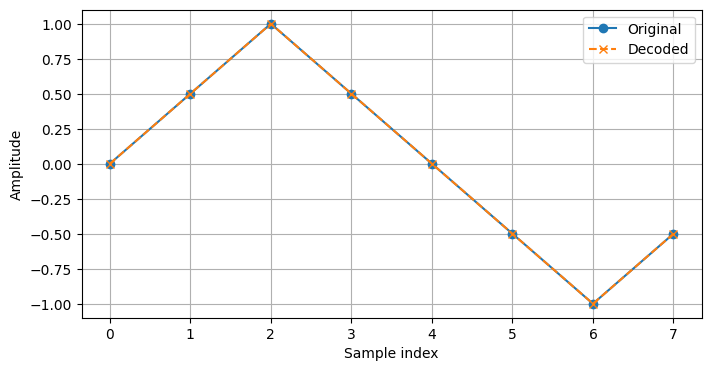

In [6]:
sample_indices = np.arange(len(toy_signal))

plt.figure(figsize=(8, 4))
plt.plot(
    sample_indices,
    toy_signal,
    "o-",
    label="Original",
)
plt.plot(
    sample_indices,
    decoded_signal,
    "x--",
    label="Decoded",
)

plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.ylim(-1.1, 1.1)
plt.xticks(sample_indices)
plt.grid(True)
plt.legend()
plt.show()